# TALLER INTEGRACIÓN Y DIFERENCIACIÓN 

## Ejercicio 1: Integración de una función

### A. Análisis matemático

1. Expresión análitica de la integral

La integral a evaluar es: $I = \int_{0}^{8} e^{-0.4x}(1+sen(3x))dx$

Expandiendo la integral a la suma de dos terminos quedaría:  $I = \int_{0}^{8} e^{-0.4x}dx + \int_{0}^{8} e^{-0.4x}sen(3x)$

Se puede observar que el primer termino es una simple integral exponencial y el segundo es el producto entre una exponencial y una función trigonométrica. Ambas integrales tiene una solución que converge y es facil de hallar analitícamente, siendo la segunda la más complicada al usar la integración por partes. Con ayuda de una IA se hallo la función resultante de esta integral, la cual dio:

$F(x) = -2.5e^{0.4x} - \frac{0.5e^{-0.4x}}{8.84}(0.4sen(3x) + 3cos(3x))$

Si se evalua en el intervalo dado $F(8) - F(0)$ da como resultado $I = 2.5598$

2. Representación del area acumulada

Consiste en la suma de todos los valores de f(x) ponderados por la amplitud de los respectivos subintervalos dx. Por tanto, el área acumulada representa la energía o magnitud total contenida en la señal definida en el intervalo de 0 a 8.


3. Características que afectan la aproximación numérica 

La componente oscilatoria de la función trigonométrica influye en el calculo de la integral con métodos computacionales, dado que el paso en cada método puede ignorar los puntos más altos de la función generando error dentro del cálculo acumulado. Además debido a la componente exponencial decreciente, a mayor intervalo de evaluación de la integral definida se da un problema con respecto a la aproximación numérica.


### B. GNU Octave

Se procede a ejecutar el código pertinente que se encuentra en la carpeta ***Octave/TALLER_I_D/EJERCICIO_1_B.m*** y se realiza a siguiente tabla de la regla del trapecio:

|n  |      Integral   |     Error Absoluto | Tiempo (s)|
|---|----------------|-------------------|-----------|
|10 | 2.49407251  |    6.57519981e-02 | 0.018761|
|20    |   2.54492972 |     1.48947921e-02  |0.000145|
|50    |   2.55750278  |   2.32173142e-03 | 0.000053|
|100    |  2.55924621  |    5.78300318e-04 | 0.000050|
|500   |   2.55980140   |   2.31048428e-05  | 0.000073|
|1000  |  2.55981873     | 5.77599867e-06|  0.000158|


Por otro lado, se aplica una función nativa de Octave que usa cuadratura adaptativa global:

Integral: 2.55982451 | Error: 3.55271368e-15 | Tiempo: 0.013171 s

Observando los datos obtenidos se puede concluir que a mayor cantidad de subintervalos se da un menor error absoluto, además se evidencia un punto de equilibrio en el tiempo de procesamiento. Por ende, a pesar de que el error absoluto disminuya, aumentar n indefinidamente tiene como consecuencia un mayor costo computacional sin obtener beneficio alguno en tiempo y precisión. Por último, comparando el método de la regla del trapecio con la función nativa de octave se evidencia mejor tiempo de procesamiento en la primera pero un error absoluto practicamente cero en la segunda.

### C. C/C++ con GSL

Se implemenó el código propuesto en la carpeta ***C_C++/TALLER_I_D/EJERCICIO_1_C.cpp*** y se da el siguiente resultado:

Integración con GSL (gsl_integration_qag) ---
Resultado:           2.559824508
Error estimado:      2.841976108e-14
Tolerancia absoluta: 1e-07
Tolerancia relativa: 1e-07

Integración explícita (Regla del Trapecio, n=100) ---
Resultado:           2.559246208


Se puede observar que la integración adaptativa con GSL logra una precisión superior (2.559824508) frente a la regla del trapecio explícita (2.559246208), la cual pierde exactitud en el cuarto decimal al depender fijamente del subintervalo n=100 que no se adapta bien a las oscilaciones de la función. De esta forma, el programador conserva únicamente el control del planteamiento inicial definiendo la función, el intervalo [0, 8] y las tolerancias requeridas (1e-07), mientras se le delega a la librería la estrategia de cálculo; GSL se encarga de dividir el intervalo en subsecciones según sea necesario, colocar más puntos en las zonas donde la función varía más y calcular el error estimado en tiempo real para garantizar precisión.

### D. Python con SciPy

Se usa las siguiente lineas de código para definir intervalo y función junto a la referencia de la solución analítica

In [3]:
import numpy as np
from scipy.integrate import quad
import time

# 1. Definición de la función matemática
def f(x):
    return np.exp(-0.4 * x) * (1.0 + 0.5 * np.sin(3.0 * x))

# Parámetros del intervalo y valor analítico
a = 0
b = 8
referencia = 2.55982450830206

A continuación se da las tolerancias explicitas que se dan por defecto y se da el error estimado y el tiempo de ejecución, se observa la función *quad()*

In [5]:
# Tolerancias explícitas (por defecto quad usa aprox 1.49e-8)
tolerancia_abs = 1.49e-8
tolerancia_rel = 1.49e-8

# 2. Ejecución y medición de tiempo de SciPy.quad
start_time = time.perf_counter()
resultado, error_estimado = quad(f, a, b, epsabs=tolerancia_abs, epsrel=tolerancia_rel)
end_time = time.perf_counter()

tiempo_ejecucion = end_time - start_time
error_real = abs(referencia - resultado)

Se imprimen los resultados

In [6]:
# 3. Presentación de resultados
print("--- Integración con Python (scipy.integrate.quad) ---")
print(f"Resultado:           {resultado:.10f}")
print(f"Error estimado:      {error_estimado:.4e} (Calculado internamente por quad)")
print(f"Error real vs ref:   {error_real:.4e}")
print(f"Tolerancia absoluta: {tolerancia_abs:.2e}")
print(f"Tolerancia relativa: {tolerancia_rel:.2e}")
print(f"Tiempo de ejecución: {tiempo_ejecucion:.6f} segundos")

--- Integración con Python (scipy.integrate.quad) ---
Resultado:           2.5598245083
Error estimado:      1.4583e-10 (Calculado internamente por quad)
Error real vs ref:   3.5527e-15
Tolerancia absoluta: 1.49e-08
Tolerancia relativa: 1.49e-08
Tiempo de ejecución: 0.000260 segundos


Por su parte, la integración en Python mediante scipy.integrate.quad alcanza un resultado prácticamente exacto (2.5598245083), registrando un error real de apenas 3.55E-15 respecto a la referencia analítica y un tiempo de ejecución mínimo de 0.000260 segundos. Al comparar la interfaz de SciPy con la de GSL, la diferencia clave está en el nivel de abstracción, aunque ambas librerías emplean por debajo la misma estrategia adaptativa, SciPy permite resolver la integral en una sola línea pasando la función directamente. Esto ofrece el equilibrio ideal entre la alta velocidad de cálculo de código compilado en bajo nivel y la sencillez de programación de Python.

### Preguntas de análisis


1. ¿Qué cambia en el trapecio al aumentar n?

Al aumentar el número de subintervalos $n$, se reduce el tamaño del paso $h$. En consecuencia, los trapecios se vuelven más estrechos y se ajustan mejor a la curvatura de la función generando que el error de truncamiento global disminuye de forma cuadrática, ya que está regido por $O(h^2)$. Para esta función particular, aumentar $n$ es necesario para capturar las oscilaciones de alta frecuencia generadas por el término trigonométrico y evitar el "aliasing" que ocurre si los nodos caen lejos de los picos y valles de la señal. El costo computacional aumenta de forma lineal proporcional a $n$.

2. ¿Qué diferencia hay entre aumentar n y reducir la tolerancia de un método adaptativo?

Aumentar $n$ en la regla del trapecio establece una malla no dinámica en todo el dominio. El algoritmo evaluará la función con la misma densidad de puntos tanto en las zonas de alta variación cerca a $x=0$, donde la exponencial cae rápido como en las zonas casi planas, desperdiciando recursos computacionales.Por el contrario, reducir la tolerancia en un método adaptativo le indica al algoritmo el límite máximo de error permitido. El método adaptativo mejorará la malla únicamente en las regiones donde la función presenta mayor variación geométrica, garantizando el cumplimiento del límite de error con el mínimo número posible de evaluaciones de la función, optimizando el costo computacional.

3. ¿Mayor precisión implica necesariamente mayor costo?
No, depende estrictamente del método empleado. En el caso de la regla del trapecio sí existe una relación directa donde alcanzar mayor precisión exige aumentar $n$, lo que incrementa linealmente el costo computacional, por ende, el tiempo de procesamiento. Sin embargo, al cambiar a un método de orden superior, se puede obtener una precisión drásticamente mayor realizando una fracción mínima de las evaluaciones requeridas por el trapecio. 

4. Compare el error estimado por GSL/SciPy con el error respecto a la referencia.

El error estimado que entregan GSL o SciPy es un valor interno que el algoritmo calcula de forma autónoma sin conocer la respuesta real. Lo hace comparando dos reglas de integración de diferente orden y usando la diferencia entre ambas como cota de error. Suele ser un cálculo para garantizar que se cumple la tolerancia impuesta.El error real es la diferencia entre el cálculo analítico y el valor numérico obtenido. 


##  Ejercicio 2: integración de 50 datos equiespaciados


### A. Preparación

Con el siguiente código se realzia el archivo CSV con la función declarada en el ejercicio 

In [8]:
import numpy as np
import pandas as pd

# 1. Generar los índices i del 0 al 49
i = np.arange(50)

# 2. Calcular los valores de x e y según las ecuaciones del taller
x = 0.2 * i
y = 2.0 + 0.35 * np.sin(0.7 * x) + 0.15 * np.cos(2.1 * x) + 0.03 * x

# 3. Empaquetar los datos y guardarlos como CSV
df = pd.DataFrame({'x': x, 'y': y})
df.to_csv('datos_sensor.csv', index=False)

print("Archivo 'datos_sensor.csv' generado exitosamente con la siguiente estructura:")
print(f"Total de datos (filas): {len(df)}")
print("\nPrimeras 5 mediciones:")
print(df.head())

Archivo 'datos_sensor.csv' generado exitosamente con la siguiente estructura:
Total de datos (filas): 50

Primeras 5 mediciones:
     x         y
0  0.0  2.150000
1  0.2  2.191803
2  0.4  2.208844
3  0.6  2.206589
4  0.8  2.193567


### B. GNU Octave

Se ejecuta el código que se encuentra en ***Octave/TALLER_I_D/EJERCICIO_2_B.m***. Segun las condicones se evalua primero con al regla de simpson para todo el intervalo par, sin embargo debido a que el intervalo total es impar de 0 a 49, los ultimos dos datos se evaluan con la regla del trapecio. Se observa la gráfica resultante:

<p align="center">
  <img src="are_bajo.png" />
</p>

Resultados de Integración Numérica (Datos discretos) 

**Integral mediante Trapecio:** 21.190846

**Integral mediante Simpson (Ajustado):** 21.191953

### C. C/C++ con GSL

Se ejecuta el código en ***C_C++/TALLER_I_D/EJERCICIO_2_C*** y se dan los siguientes resultados:

--- Integración con datos discretos (C/C++) ---

Integral Trapecio Explicito: 21.1908

--- Integración mediante Interpolación Cúbica (GSL) ---

Integral GSL (Spline):       21.1919
Error estimado:              5.72268e-07


Al integrar las 50 mediciones discretas, el trapecio explícito obtiene 21.1908 frente a los 21.1919 de la interpolación por splines en GSL, una pequeña diferencia (\approx 0.0011) debida a que el trapecio es un método rápido y robusto que no distorsiona la información al unir puntos con rectas pero pierde precisión al ignorar la curvatura, mientras que el spline logra reconstruir la continuidad física del fenómeno a costa de un mayor costo computacional y una mayor sensibilidad al ruido. Integrar directamente los datos discretos frente a construir una función interpolada representa un compromiso fundamental entre simplicidad computacional.


**Integración directa (Trapecio)**: Es ultra rápida, liviana y no genera oscilaciones falsas ante datos ruidosos, aunque pierde precisión al asumir trayectorias rectas entre mediciones. 


**Interpolación previa (Splines Cúbicos)**: Reconstruye la continuidad y curvatura física suave de la señal permitiendo reevaluar cualquier punto intermedio, pero incrementa el costo computacional y tiende a amplificar el ruido de medición.

### D. Python con SciPy

Se procede a extraer los datos del CSV y se aplcain mediante el uso de listas las dos funciones para integrar de la libreria de scipy, *trapezoid()* y *simpson()* se dan los siugientes resultados

In [10]:
import numpy as np
from scipy.integrate import trapezoid, simpson

# 1. Cargar los datos desde el archivo CSV
data = np.loadtxt("datos_sensor.csv", delimiter=",", skiprows=1)

# 2. Extraer las columnas de x e y
x = data[:, 0]
y = data[:, 1]

# 3. Calcular la integral mediante los dos métodos
I_trap = trapezoid(y, x)
I_simp = simpson(y, x=x)

# 4. Mostrar resultados
print("--- Integración de datos discretos con Python (SciPy) ---")
print(f"Integral mediante Trapecio: {I_trap:.6f}")
print(f"Integral mediante Simpson:  {I_simp:.6f}")
print(f"Diferencia absoluta:        {abs(I_trap - I_simp):.6f}")

--- Integración de datos discretos con Python (SciPy) ---
Integral mediante Trapecio: 21.190846
Integral mediante Simpson:  21.192113
Diferencia absoluta:        0.001267


En Python con SciPy, la integración de las 50 mediciones discretas da 21.190846 mediante la regla del trapecio y 21.192113 con la regla de Simpson, reflejando una leve diferencia de 0.001267 debida a que el trapecio aproxima la trayectoria uniendo los puntos mediante segmentos de recta ($O(h^2)$), mientras que Simpson ajusta parábolas cuadráticas sobre tríos de puntos consecutivos ($O(h^4)$), logrando capturar con mayor fidelidad la curvatura continua de la señal directamente desde la librería con una ejecución prácticamente instantánea.


## Extensión: diferenciación numérica


Se realiza la comparación aplicamos las aproximaciones de diferencias finitas hacia adelante y diferencias finitas centrales. 


### SciPy 

Matplotlib is building the font cache; this may take a moment.


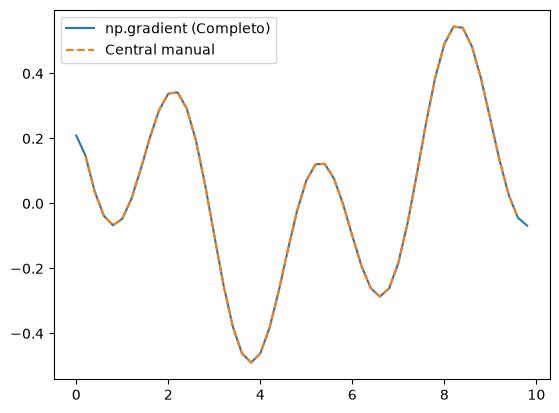

In [11]:
import matplotlib.pyplot as plt

data = np.loadtxt("datos_sensor.csv", delimiter=",", skiprows=1)
x = data[:, 0]; y = data[:, 1]
h = x[1] - x[0]

# Cálculo manual según las fórmulas del taller
df_forward = (y[1:] - y[:-1]) / h
df_central = (y[2:] - y[:-2]) / (2*h)

# Función nativa de NumPy (Usa diferencias centrales en el interior 
# y diferencias hacia adelante/atrás en los bordes)
df_numpy = np.gradient(y, h)

plt.plot(x, df_numpy, label="np.gradient (Completo)")
plt.plot(x[1:-1], df_central, '--', label="Central manual")
plt.legend(); plt.show()

### C/C++ GSL





Se ejecuta el código en ***C_C++/TALLER_I_D/DIF_NUM.cpp*** se dieron los sigientes resultados:



| Índice | x | Hacia Adelante | Central |
| --- | --- | --- | --- |
| 1 | 0.2000 | 0.0852 | 0.1471 |
| 2 | 0.4000 | -0.0113 | 0.0370 |
| 3 | 0.6000 | -0.0651 | -0.0382 |
| 4 | 0.8000 | -0.0691 | -0.0671 |
| 5 | 1.0000 | -0.0253 | -0.0472 |

### GNU Octave 



Se da la siugiente gráfica con el código en ***Octave/TALLER_I_D/DIF_NUM.cpp***, el cual se ofrece la siguiente gráfica:

<p align="center">
  <img src="octave_dif.png" />
</p>

### Comparación

1. Comparación de los métodos (Hacia Adelante vs. Diferencia Central)
En los tres entornos evaluados, la diferencia central ($O(h^2)$) demuestra una precisión claramente superior a la diferencia hacia adelante ($O(h)$). Al analizar los datos discretos, la regla hacia adelante genera un desfasamiento horizontal en la curva debido a que calcula la pendiente usando el punto actual y el siguiente ($x_i y x_{i+1}$), atribuyendo la variación completa al inicio del subintervalo. En contraste, la regla de diferencia central evalúa un entorno simétrico alrededor de x_i, lo que le permite capturar con exacta alineación la curvatura local y amplitud de los picos.
2. Tratamiento de los extremos del vector
Respecto al tratamiento de los extremos, el esquema de diferencia central enfrenta una restricción física en las fronteras de los datos, ya que el primer punto ($i=0$) carece de un vecino a la izquierda ($x_{-1}$) y el último punto ($i=N$) carece de un vecino a la derecha ($x_{N+1}$). Para resolver este dilema sin recortar la longitud del vector ni perder información en los bordes, las herramientas nativas como np.gradient en Python o gradient en Octave aplican un esquema híbrido: utilizan diferencia hacia adelante en el primer punto ($i=0$), diferencia hacia atrás en el último punto ($i=N$), y reservan la diferencia central para la totalidad de los puntos internos. En C++ con GSL, este mismo criterio debe programarse de forma explícita en los bucles o manejarse tras la construcción de una malla de interpolación.  
3. Sensibilidad al ruido: Diferenciación vs. Integración
Por último, la sensibilidad al ruido marca una diferencia conceptual crítica entre la naturaleza de ambos operadores numéricos. Mientras que la integración actúa como un proceso de suavizado donde la acumulación de áreas y la suma de errores aleatorios de medición tienden a promediarse y cancelarse a lo largo del intervalo, la diferenciación opera como un amplificador de perturbaciones de alta frecuencia. Al restarle a una medición su dato contiguo y dividir esa diferencia entre un paso de discretización pequeño, cualquier pequeño ruido experimental introducido por el sensor se incrementa, produciendo picos falsos e inestabilidad.

##  Comparación final - Tabla



| Criterio | GNU Octave | C/C++ + GSL | Python + SciPy |
| :--- | :--- | :--- | :--- |
| **Facilidad de implementación** | Alta. Operaciones vectorizadas faciles de trabajar. | Media. Exige gestión manual de memoria, punteros y compilación. | Alta. Sintaxis clara, función Python estándar e implementación rápida. |
| **Control** | Medio. Configuraciones algorítmicas altamente abstraídas por defecto. | Muy alto. Control explícito sobre subdivisiones, espacio de trabajo y reglas de integración. | Alto. Abstracción limpia pero permite modificar fácilmente los parámetros internos. |
| **Manejo de tolerancias** | Opcional y gestionado internamente por defecto en sus rutinas. | Obligatorio. Se exige definir explícitamente `epsabs` y `epsrel` en la interfaz central. | Opcional y directo. Se pasan como argumentos específicos a rutinas como `quad`. |
| **Integración de funciones** | Alta, definición directa y flexible de funciones. | Requiere crear *callbacks* compatibles y empaquetar variables en punteros `void*`. | Interfaz de alto nivel muy directa utilizando `scipy.integrate.quad` y otras rutinas. |
| **Integración de datos** | Excelente. Funciones sin necesidad de bucles. | Complicado. Requiere bucles iterativos manuales o construir rutinas interpoladoras. | Excelente. Uso conjunto de arreglos NumPy con funciones como `trapezoid` o `simpson`. |
| **Estimación del error** | Requiere rutinas específicas o cálculo manual contra referencias. | Estimación algorítmica obligatoria devuelta en las variables de salida por paso por referencia. | Entregada automáticamente como segundo elemento en la tupla de respuesta (`resultado, error`). |
| **Tiempo de ejecución** | Moderado a rápido. | Muy rápido (costo computacional bajo). Ventaja del lenguaje de maquina compilado. | Rápido. Python delega la ejecución de bajo nivel a bibliotecas precompiladas en C. |
| **Visualización** | Nativa, rápida e integrada sin librerias extra. | Inexistente de forma nativa. Requiere exportar a `.csv` y grafiar en ese entorno. | Nativa e integrada apoyándose en el entorno (Matplotlib). |


## Reflexión y Evocación

1. Esta pérdida de información obliga a cambiar la estrategia: en lugar de refinar la evaluación dinámicamente, se deben usar métodos fijos para vectores (como la regla del trapecio o de Simpson) o aplicar una interpolación previa (por ejemplo, con splines) para aproximar la continuidad de la señal antes de calcular la integral o la derivada.


2. El desarrollo del taller en los tres entornos permite rescatar cinco conceptos clave de la computación numérica:  

- *Discretización*: El paso h determina la resolución del problema. Si h es muy grande se pierde precisión, pero si es demasiado pequeño se incrementa el costo de cómputo innecesariamente.

- *Error*: El orden del método define su exactitud. Reglas como Simpson ($O(h^4)$) aprovechan mejor la curvatura de los datos equiespaciados que la regla del trapecio ($O(h^2)$).

- *Representación de datos:* Modifica la forma de programar. Python y Octave manejan los arreglos de datos en memoria de forma automática, mientras que C/C++ exige reservar memoria, usar punteros y construir callbacks manualmente.

- *Abstracción de bibliotecas:* Determina el balance entre facilidad y desempeño. Python + SciPy ofrece la interfaz más ágil para procesar datos y graficar con Matplotlib; GNU Octave permite un prototipado vectorial rápido con gráficos nativos; y C/C++ + GSL requiere mayor esfuerzo de código pero entrega el mayor control sobre el algoritmo y el menor tiempo de ejecución.